In [1]:
import pandas as pd
TFT_pred=pd.read_csv("TFT_preds.csv")
df_grouped = TFT_pred.groupby('Name', as_index=False).mean()
df_grouped.to_csv("TFT_preds.csv")

XGB_pred=pd.read_csv("XGB_preds.csv")
df_grouped = XGB_pred.groupby('Name', as_index=False).mean()
df_grouped.to_csv("XGB_preds.csv")

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_26008\2385154729.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [20]:
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
response = requests.get(url)
json_data = response.json()
elements_df = pd.DataFrame(json_data['elements'])
print(elements_df.columns)
data_points=elements_df[["id", "second_name", "team","first_name","code","news","element_type","team_code","web_name"]]
ids=data_points["id"].unique()
data=pd.read_csv("Fantasy_season_2024_data.csv").iloc[:,1:]
print(data)
max_gw=max(data["round"].unique())
print(max_gw)
full_df=pd.DataFrame()
for i in range(len(ids)):
    player_id=ids[i]
    id_df=data_points[data_points["id"]==player_id]
    base_url = "https://fantasy.premierleague.com/api/element-summary/"
    full_url = base_url + str(player_id) + "/"
    response = requests.get(full_url)
    data = json.loads(response.text)
    df=pd.DataFrame(data['history'])
    df=df[df["round"]==max_gw]
    replicated_id_df = pd.concat([id_df] * len(df), ignore_index=True)
    df[["id", "second_name", "team","first_name","code","news","element_type","team_code"]]=replicated_id_df[["id", "second_name", "team","first_name","code","news","element_type","team_code"]]
    df["Full_Name"]=df["first_name"]+"_"+df["second_name"]
    full_df=pd.concat([full_df, df], axis=0, ignore_index=True)

url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
response = requests.get(url)
json_data = response.json()
team_data = pd.DataFrame(json_data['teams'])
elements_types_df = pd.DataFrame(json_data['element_types'])
full_df = full_df.merge(
    team_data[['id', 'code', 'name']],  # Select necessary columns from team_data
    left_on='opponent_team',           # Column in season_data
    right_on='id',                     # Column in team_data
    how='left'                         # Use a left join to preserve all rows from season_data
)
full_df.rename(columns={'code_y': 'opponent_code', 'name': 'opponent_name'}, inplace=True)
full_df.drop(columns=['id_y'], inplace=True)
full_df = full_df.merge(
    team_data[['id', 'code', 'name']],  # Select necessary columns from team_data
    left_on='team',           # Column in season_data
    right_on='id',                     # Column in team_data
    how='left'                         # Use a left join to preserve all rows from season_data
)
full_df.rename(columns={'code': 'team_code2', 'name': 'team_name'}, inplace=True)
full_df.drop(columns=['id'], inplace=True)
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
response = requests.get(url)
json_data = response.json()
elements_df = pd.DataFrame(json_data['elements'])
elements_types_df = pd.DataFrame(json_data['element_types'])
full_df = full_df.merge(
    elements_types_df[['id', 'singular_name_short']],  # Select necessary columns from team_data
    left_on='element_type',           # Column in season_data
    right_on='id',                     # Column in team_data
    how='left'                         # Use a left join to preserve all rows from season_data
)
full_df.rename(columns={'singular_name_short': 'position'}, inplace=True)
print(full_df)
full_df.drop(columns=['id'], inplace=True)

old_data=data[data["round"]!=max_gw]
inc_data=pd.concat([old_data, full_df], axis=0, ignore_index=True)
inc_data.to_csv("Raw_Data_24/Fantasy_season_2024_data.csv")
fixtures()

Index(['can_transact', 'can_select', 'chance_of_playing_next_round',
       'chance_of_playing_this_round', 'code', 'cost_change_event',
       'cost_change_event_fall', 'cost_change_start', 'cost_change_start_fall',
       'dreamteam_count', 'element_type', 'ep_next', 'ep_this', 'event_points',
       'first_name', 'form', 'id', 'in_dreamteam', 'news', 'news_added',
       'now_cost', 'photo', 'points_per_game', 'removed', 'second_name',
       'selected_by_percent', 'special', 'squad_number', 'status', 'team',
       'team_code', 'total_points', 'transfers_in', 'transfers_in_event',
       'transfers_out', 'transfers_out_event', 'value_form', 'value_season',
       'web_name', 'region', 'team_join_date', 'minutes', 'goals_scored',
       'assists', 'clean_sheets', 'goals_conceded', 'own_goals',
       'penalties_saved', 'penalties_missed', 'yellow_cards', 'red_cards',
       'saves', 'bonus', 'bps', 'influence', 'creativity', 'threat',
       'ict_index', 'starts', 'expected_goals', 


KeyboardInterrupt



In [7]:
import pandas as pd
season_data=pd.read_csv("Fantasy_season_2024_data.csv")
team_data=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/teams.csv")
season_data = season_data.merge(
    team_data[['id', 'code', 'name']],  # Select necessary columns from team_data
    left_on='opponent_team',           # Column in season_data
    right_on='id',                     # Column in team_data
    how='left'                         # Use a left join to preserve all rows from season_data
)
season_data.rename(columns={'code_y': 'opponent_code', 'name': 'opponent_name'}, inplace=True)
season_data.drop(columns=['id_y'], inplace=True)
season_data = season_data.merge(
    team_data[['id', 'code', 'name']],  # Select necessary columns from team_data
    left_on='team',           # Column in season_data
    right_on='id',                     # Column in team_data
    how='left'                         # Use a left join to preserve all rows from season_data
)
season_data.rename(columns={'code': 'team_code', 'name': 'team_name'}, inplace=True)
print(season_data)
season_data.drop(columns=['id'], inplace=True)

# Display the updated DataFrame
print(season_data)

       Unnamed: 0  element  fixture  opponent_team  total_points  was_home  \
0               0        1        2             20             0      True   
1               1        1       11              2             0     False   
2               2        1       21              5             0      True   
3               3        1       39             18             0     False   
4               4        1       47             13             0     False   
...           ...      ...      ...            ...           ...       ...   
11324       11324      682      130              3             0      True   
11325       11325      682      134              8             0     False   
11326       11326      682      150             19             0     False   
11327       11327      682      160             10             0      True   
11328       11328      682      167             11             0     False   

               kickoff_time  team_h_score  team_a_score  round 

In [13]:
season_data=pd.read_csv("Fantasy_season_2024_data.csv")
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
response = requests.get(url)
json_data = response.json()
elements_df = pd.DataFrame(json_data['elements'])
elements_types_df = pd.DataFrame(json_data['element_types'])
season_data = season_data.merge(
    elements_types_df[['id', 'singular_name_short']],  # Select necessary columns from team_data
    left_on='element_type',           # Column in season_data
    right_on='id',                     # Column in team_data
    how='left'                         # Use a left join to preserve all rows from season_data
)
season_data.rename(columns={'singular_name_short': 'position'}, inplace=True)
season_data.drop(columns=['id_y'], inplace=True)
print(season_data)

       Unnamed: 0  element  fixture  opponent_team  total_points  was_home  \
0               0        1        2             20             0      True   
1               1        1       11              2             0     False   
2               2        1       21              5             0      True   
3               3        1       39             18             0     False   
4               4        1       47             13             0     False   
...           ...      ...      ...            ...           ...       ...   
11324       11324      682      130              3             0      True   
11325       11325      682      134              8             0     False   
11326       11326      682      150             19             0     False   
11327       11327      682      160             10             0      True   
11328       11328      682      167             11             0     False   

               kickoff_time  team_h_score  team_a_score  round 

In [16]:
url = "https://fantasy.premierleague.com/api/fixtures/"
response = requests.get(url)
json_data = response.json()
df=pd.DataFrame(json_data)
print(df)

        code  event  finished  finished_provisional   id  \
0    2444613    NaN     False                 False  144   
1    2444470    1.0      True                  True    1   
2    2444473    1.0      True                  True    4   
3    2444471    1.0      True                  True    2   
4    2444472    1.0      True                  True    3   
..       ...    ...       ...                   ...  ...   
375  2444845   38.0     False                 False  376   
376  2444846   38.0     False                 False  377   
377  2444847   38.0     False                 False  378   
378  2444848   38.0     False                 False  379   
379  2444849   38.0     False                 False  380   

             kickoff_time  minutes  provisional_start_time started  team_a  \
0                    None        0                    True    None      12   
1    2024-08-16T19:00:00Z       90                   False    True       9   
2    2024-08-17T11:30:00Z       90           

In [11]:
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
response = requests.get(url)
json_data = response.json()
elements_df = pd.DataFrame(json_data['elements'])
elements_types_df = pd.DataFrame(json_data['element_types'])
teams_df = pd.DataFrame(json_data['teams'])
print(elements_types_df)

   id  plural_name plural_name_short singular_name singular_name_short  \
0   1  Goalkeepers               GKP    Goalkeeper                 GKP   
1   2    Defenders               DEF      Defender                 DEF   
2   3  Midfielders               MID    Midfielder                 MID   
3   4     Forwards               FWD       Forward                 FWD   

   squad_select squad_min_select squad_max_select  squad_min_play  \
0             2             None             None               1   
1             5             None             None               3   
2             5             None             None               2   
3             3             None             None               1   

   squad_max_play  ui_shirt_specific sub_positions_locked  element_count  
0               1               True                 [12]             73  
1               5              False                   []            237  
2               5              False                   [] 

In [49]:
import pandas as pd
import os
import requests

players24=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/gws/merged_gw.csv")[["name","position","team"]]
players24[['first_name', 'second_name']] = players24['name'].str.split(' ', n=1, expand=True)
team_ids_2024 = pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/teams.csv")
players24 = players24.drop_duplicates()
players24_with_codes = players24.merge(team_ids_2024[['name','code']], left_on='team', right_on='name', how='left')
players24=players24_with_codes[['first_name', 'second_name', 'position', 'code']]

players23=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/gws/merged_gw.csv")[["name","position","team"]]
players23[['first_name', 'second_name']] = players23['name'].str.split(' ', n=1, expand=True)
team_ids_2023 = pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/teams.csv")
players23 = players23.drop_duplicates()
players23_with_codes = players23.merge(team_ids_2023[['name','code']], left_on='team', right_on='name', how='left')
players23=players23_with_codes[['first_name', 'second_name', 'position', 'code']]

old_players=pd.concat([players23, players24], axis=0, ignore_index=True)
old_players = old_players.drop_duplicates()
old_players.rename(columns={'code': 'team_code'}, inplace=True)
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
response = requests.get(url)
json_data = response.json()
elements_df = pd.DataFrame(json_data['elements'])
elements_types_df = pd.DataFrame(json_data['element_types'])
teams_df = pd.DataFrame(json_data['teams'])
    
slim_elements_df = elements_df[['id','first_name','second_name','team_code','element_type','team']]
    
slim_elements_df['position'] = slim_elements_df.element_type.map(elements_types_df.set_index('id').singular_name)
slim_elements_df['team'] = slim_elements_df.team.map(teams_df.set_index('id').name)
slim_elements_df=slim_elements_df[['first_name','second_name','position','team_code']]
position_mapping = {
    'Forward': 'FWD',
    'Midfielder': 'MID',
    'Goalkeeper': 'GK',
    'Defender':'DEF'}
    
slim_elements_df['position'] = slim_elements_df['position'].map(position_mapping).fillna(slim_elements_df['position'])
slim_elements_df=pd.concat([slim_elements_df, old_players], axis=0, ignore_index=True)
slim_elements_df=slim_elements_df.drop_duplicates()
slim_elements_df.rename(columns={'code': 'team_code'}, inplace=True)

# Display the resulting DataFrame with the 'code' column added
slim_elements_df.to_csv('all_players.csv')


     first_name second_name position  team_code
0        Nathan     Redmond      MID         20
1        Junior   Stanislas      MID         91
2       Armando       Broja      FWD          8
3        Fabian       Schär      DEF          4
4         Jonny       Evans      DEF         13
...         ...         ...      ...        ...
1692     Tyrese        Hall      MID          6
1693       Noël        Atom      DEF         36
1694     Lander       Emery       GK          7
1696      Billy     Crellin       GK         11
1697      Yunus       Konak      MID         94

[1231 rows x 4 columns]
      id    first_name             second_name  team_code  element_type  \
0      1         Fábio         Ferreira Vieira          3             3   
1      2       Gabriel       Fernando de Jesus          3             4   
2      3       Gabriel    dos Santos Magalhães          3             2   
3      4           Kai                 Havertz          3             4   
4      5          Karl  

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_41732\1040540308.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slim_elements_df['position'] = slim_elements_df.element_type.map(elements_types_df.set_index('id').singular_name)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_41732\1040540308.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slim_elements_df['team'] = slim_elements_df.team.map(teams_df.set_index('id').name)


In [17]:
import pandas as pd
import os

data_folder = "clone\Fantasy-Premier-League\data\2022-23"
data_folder = "Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23"
folders = [f for f in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, f))]
print(folders)
teams=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/teams2.csv")[["code","name", "XGH","XGCH","XGA","XGCA"]]
teams4=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/teams2.csv")[["code","name", "XGH","XGCH","XGA","XGCA"]]
a=pd.concat([teams,teams4],
                  axis = 0)

cluster_data=a.iloc[:,2:].values

print(a)
print(cluster_data)

['gws', 'players', 'understat']
    code            name   XGH  XGCH   XGA  XGCA
0      3         Arsenal  2.55   1.1  1.70   1.2
1      7     Aston Villa  1.60   1.2  1.05   1.5
2     91     Bournemouth  1.10   1.5  0.85   1.9
3     94       Brentford  1.80   1.1  1.25   1.5
4     36        Brighton  2.10   1.2  1.70   1.5
5      8         Chelsea  1.25   1.3  1.05   1.5
6     31  Crystal Palace  1.08   1.3  1.00   1.3
7     11         Everton  1.05   1.4  1.10   2.1
8     54          Fulham  1.45   1.6  1.20   1.8
9     13       Leicester  1.20   1.4  1.50   2.0
10     2           Leeds  1.40   1.7  1.20   1.8
11    14       Liverpool  2.25   1.1  1.60   1.7
12    43        Man City  2.80   0.7  1.80   1.0
13     1         Man Utd  2.00   1.0  1.35   1.6
14     4       Newcastle  2.10   0.9  1.60   1.3
15    17   Nott'm Forest  1.30   1.6  0.70   1.8
16    20     Southampton  1.05   1.6  0.90   1.7
17     6           Spurs  1.80   1.1  1.60   1.6
18    21        West Ham  1.40   1.3 

<>:4: SyntaxWarning: invalid escape sequence '\F'
<>:4: SyntaxWarning: invalid escape sequence '\F'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_70432\3616566077.py:4: SyntaxWarning: invalid escape sequence '\F'
  data_folder = "clone\Fantasy-Premier-League\data\2022-23"


    code            name   XGH  XGCH   XGA  XGCA  predict
0      3         Arsenal  2.55   1.1  1.70   1.2        2
1      7     Aston Villa  1.60   1.2  1.05   1.5        4
2     91     Bournemouth  1.10   1.5  0.85   1.9        3
3     94       Brentford  1.80   1.1  1.25   1.5        4
4     36        Brighton  2.10   1.2  1.70   1.5        0
5      8         Chelsea  1.25   1.3  1.05   1.5        4
6     31  Crystal Palace  1.08   1.3  1.00   1.3        4
7     11         Everton  1.05   1.4  1.10   2.1        3
8     54          Fulham  1.45   1.6  1.20   1.8        1
9     13       Leicester  1.20   1.4  1.50   2.0        1
10     2           Leeds  1.40   1.7  1.20   1.8        1
11    14       Liverpool  2.25   1.1  1.60   1.7        0
12    43        Man City  2.80   0.7  1.80   1.0        2
13     1         Man Utd  2.00   1.0  1.35   1.6        0
14     4       Newcastle  2.10   0.9  1.60   1.3        0
15    17   Nott'm Forest  1.30   1.6  0.70   1.8        3
16    20     S

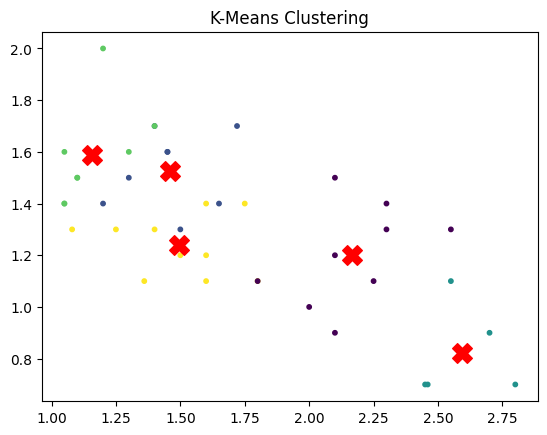

In [18]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=5, random_state=31)
kmeans.fit(cluster_data)

a["predict"]=kmeans.predict(cluster_data)
print(a)
plt.scatter(cluster_data[:, 0], cluster_data[:, 1], c=kmeans.labels_, s=10, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200, color='red')
plt.title("K-Means Clustering")
plt.show()



In [19]:

player_hist=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/cleaned_merged_seasons.csv")[["season_x","name","position","team_x","assists","bonus","bps","clean_sheets","element","goals_conceded","goals_scored","minutes","opponent_team","opp_team_name","round","saves","total_points","value","was_home","GW"]]
sa = player_hist['season_x'].str.split('-', expand=True)[0].astype(int)**2+player_hist["GW"]
print(sa)




player_hist["Dataname"]=player_hist['name'].str.replace(' ', '_')
player_hist["date"]=sa
print(player_hist["date"].values[0])
player_hist.to_csv("player_history.csv")

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_70432\947002378.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  player_hist=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/cleaned_merged_seasons.csv")[["season_x","name","position","team_x","assists","bonus","bps","clean_sheets","element","goals_conceded","goals_scored","minutes","opponent_team","opp_team_name","round","saves","total_points","value","was_home","GW"]]


0        4064257
1        4064257
2        4064257
3        4064257
4        4064257
          ...   
96164    4088522
96165    4088522
96166    4088522
96167    4088522
96168    4088522
Length: 96169, dtype: int64
4064257


In [28]:
import pandas as pd
import glob
team_ids=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/master_team_list.csv")
team_ids=team_ids[team_ids['season'].str.contains('2022-23')]

# Define the directory where your CSV files are located
def history_player(name, team_id,id_string2):
    directory_path = 'Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/players/'

    # Use glob to find CSV files containing 'trippier' in their names
    matching_files = glob.glob(f'{directory_path}*{name}*')

    # Check if any matching files were found
    df=pd.DataFrame()
    if not matching_files:
        matching_files = glob.glob(f'{directory_path}*{id_string2}*')
        
    if not matching_files:
        found=False
        print("No matching files found.")
    else:
        found=True
        # Assuming you want to read the first matching file
        file_path = matching_files[0]
        split_path=file_path.split("\\")
        f=file_path+'/gw.csv'
        #f = f.replace('\'', '/')
     
        import os

        player_name = split_path[-1]
        file_path = os.path.join('Fantasy-Premier-League','Fantasy-Premier-League', 'data', '2022-23', 'players', player_name, 'gw.csv')

        # Read the CSV file into a pandas DataFrame
        df = pd.read_csv(file_path)[['assists', 'bonus', 'bps', 'clean_sheets','element',
           'expected_assists', 'expected_goal_involvements', 'expected_goals',"kickoff_time",
           'expected_goals_conceded','fixture', 'goals_conceded', 'goals_scored','minutes','opponent_team','saves','total_points','value', 'was_home']]
      
        opp_cluster=[]
        XGH=[]
        XGCH=[]
        XGA=[]
        XGCA=[]
        own_cluster=[]
        for i in range(len(df)):
            opponent=df["opponent_team"].values[i]
            
            opp_name=team_ids[(team_ids['team']==opponent)]["team_name"].values[0]
            opp_stat=teams[(teams['name']==opp_name)].iloc[:,2:].values
            own_team_name=team_ids[(team_ids['team']==team_id)]["team_name"].values[0]
            own_stat=teams[(teams['name']==own_team_name)].iloc[:,2:].values
            
            
            XGH.append(opp_stat[0][0])
            XGCH.append(opp_stat[0][1])
            XGA.append(opp_stat[0][2])
            XGCA.append(opp_stat[0][3])
            
            cluster=kmeans.predict(opp_stat)[0]
            opp_cluster.append(cluster)
            o_cluster=kmeans.predict(own_stat)[0]
            own_cluster.append(o_cluster)

        # Display the first few rows of the DataFrame
        df["Cluster"]=opp_cluster
        df["XGH"]=XGH
        df["XGCH"]=XGCH
        df["XGA"]=XGA
        df["XGCA"]=XGCA
        df["Own_cluster"]=own_cluster

    return found, df

team_ids2=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/master_team_list.csv")
team_ids2=team_ids2[team_ids2['season'].str.contains('2023-24')]
print(team_ids2)

# Define the directory where your CSV files are located
def new_player(name,team_id,id_string2):
    directory_path = 'Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/players/'

    # Use glob to find CSV files containing 'trippier' in their names
    matching_files = glob.glob(f'{directory_path}*{name}*')
    df=pd.DataFrame()

    # Check if any matching files were found
    if not matching_files:
        matching_files = glob.glob(f'{directory_path}*{id_string2}*')
    if not matching_files:
        found=False
        print("No matching files found.")
        own_team_name=teams4[(teams4['code']==team_id)].values[0][1]
    else:
        found=True
        # Assuming you want to read the first matching file
        file_path = matching_files[0]
        split_path=file_path.split("\\")
        f=file_path+'/gw.csv'
        #f = f.replace('\'', '/')
       
        import os

        player_name = split_path[-1]
        file_path = os.path.join('Fantasy-Premier-League','Fantasy-Premier-League', 'data', '2023-24', 'players', player_name, 'gw.csv')

        # Read the CSV file into a pandas DataFrame
        df = pd.read_csv(file_path)[['assists', 'bonus', 'bps', 'clean_sheets','element',
           'expected_assists', 'expected_goal_involvements', 'expected_goals',"kickoff_time",
           'expected_goals_conceded','fixture', 'goals_conceded', 'goals_scored','minutes','opponent_team','saves','total_points','value', 'was_home']]
        
        opp_cluster=[]
        XGH=[]
        XGCH=[]
        XGA=[]
        XGCA=[]
        own_cluster=[]
        

        for i in range(len(df)):
            opponent=df["opponent_team"].values[i]
            own_stat=teams4[(teams4['code']==team_id)].iloc[:,2:].values
            own_team_name=teams4[(teams4['code']==team_id)].values[0][1]
                 
            opp_stat=teams4.iloc[:,2:].values[opponent-1]
            XGH.append(opp_stat[0])
            XGCH.append(opp_stat[1])
            XGA.append(opp_stat[2])
            XGCA.append(opp_stat[3])
      
            cluster=kmeans.predict([opp_stat])[0]
            opp_cluster.append(cluster)
            o_cluster=kmeans.predict(own_stat)[0]
            own_cluster.append(o_cluster)

        # Display the first few rows of the DataFrame
        df["Cluster"]=opp_cluster
        df["XGH"]=XGH
        df["XGCH"]=XGCH
        df["XGA"]=XGA
        df["XGCA"]=XGCA
        df["Own_cluster"]=own_cluster
        print(own_cluster)
 
    return found, df,own_team_name
        




fixtures=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/master_team_list.csv")

Empty DataFrame
Columns: [season, team, team_name]
Index: []


In [13]:
fixtures=team_ids2=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/fixtures.csv")
fixtures=fixtures[(fixtures['finished']==False)].iloc[1:,:]
GW_now=fixtures["event"].values[0]
nxt_GW=fixtures[(fixtures['event']==GW_now)]
print(nxt_GW)



IndexError: index 0 is out of bounds for axis 0 with size 0

In [21]:
def next_opp(team, n_future):
    fixtures=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/fixtures.csv")
    fixtures=fixtures[(fixtures['finished']==False)].iloc[0:,:]
    filtered_fix = fixtures[(fixtures['team_a'] == team) | (fixtures['team_h'] == team)]
    filtered_fix=filtered_fix[filtered_fix["provisional_start_time"]==False]
    clusters=[]
    XGH=[]
    XGCH=[]
    XGA=[]
    XGCA=[]
    home=[]
    n_matches=[]
    kl=0
    for j in range(n_future):
        GW_now=filtered_fix["event"].values[0]
        print(n_future)
        nxt_GW=filtered_fix[(filtered_fix['event']==GW_now+kl)]
 
        if len(nxt_GW)==0:
            kl+=1
            nxt_GW=filtered_fix[(filtered_fix['event']==GW_now+kl)]
        
        n_matches.append(len(nxt_GW))
    
        for k in range(len(nxt_GW)):
            if(nxt_GW["team_a"].values[k]==team):
                nxt_opp=nxt_GW["team_h"].values[k]
                home.append(False)
            else:
                nxt_opp=nxt_GW["team_a"].values[k]
                home.append(True)
            nxt_opp=int(nxt_opp)
            nxt_oppstat=teams4.iloc[:,2:].values[nxt_opp-1]
        
            
            cluster=kmeans.predict([nxt_oppstat])[0]
            clusters.append(cluster)
            XGH.append(nxt_oppstat[0])
            XGCH.append(nxt_oppstat[1])
            XGA.append(nxt_oppstat[2])
            XGCA.append(nxt_oppstat[3])
        kl+=1
    print(XGH)
    print(clusters)
    return clusters,home,n_matches,XGH,XGCH,XGA,XGCA



In [22]:
def X_P_hist(df,pos,clusters,home,n_matches):

    X_P=[]
    counter=0
    available=[]
    #saves,CS,Assist,Goal
    fordeling = {'Goalkeeper': [0.33,4,3,6], 'Defender': [0,4,3,6], 'Midfielder': [0,1,3,5], 'Forward':[0,0,3,4]}
    act_fordling=fordeling[pos]
    for q in range(len(n_matches)):
        xp=0
        matches=n_matches[q]
        av=False
        for l in range(matches):
            opponent=clusters[counter]
            home_nxt=home[counter]
            filtered_df=df[(df['Cluster']==opponent)&(df['minutes']>0)]

            if(len(filtered_df)>0):
                n=len(filtered_df)
                av=True
                xg=((filtered_df['expected_goals'].sum()+filtered_df['goals_scored'].sum())/2)/n
                xa=((filtered_df['expected_assists'].sum()+filtered_df['assists'].sum())/2)/n
                xc=((filtered_df['expected_goals_conceded'].sum()+filtered_df['goals_conceded'].sum())/2)/n
                saves=filtered_df['saves'].sum()/n
                bonus=filtered_df['bonus'].sum()/n
                xp+=xg*act_fordling[3]+xa*act_fordling[2]+(act_fordling[1])/(2*xc)+saves*act_fordling[0]+bonus
                
            else:
                xp+=0
        
            counter+=1
        
        X_P.append(xp)
        available.append(av)
    return(X_P,available)


    

In [23]:
def XP_new(df,home,n_matches):
    XP=[]
    for i in range(len(n_matches)):
        xp=0
        fordeling = {'Goalkeeper': [0.33,4,3,6], 'Defender': [0,4,3,6], 'Midfielder': [0,1,3,5], 'Forward':[0,0,3,4]}
        pos=df['position'].values[0]
        act_fordling=fordeling[pos]
        n=df['minutes'].sum()/90
        if n>0:
            
        
            xg=((float(df['expected_goals'].sum())+float(df['goals_scored'].sum()))/2)/n
           
            xa=((float(df['expected_assists'].sum())+float(df['assists'].sum()))/2)/n
         
            xc=((float(df['expected_goals_conceded'].sum())+float(df['goals_conceded'].sum()))/2)/n
            saves=float(df['saves'].sum())/n
            bonus=float(df['bonus'].sum())/n

            if n_matches[i]>1:
                xp+=2*(xg*act_fordling[3]+xa*act_fordling[2]+(act_fordling[1])/(2*xc)+saves*act_fordling[0]+bonus)
                
        
            else:
                xp+=xg*act_fordling[3]+xa*act_fordling[2]+(act_fordling[1])/(2*xc)+saves*act_fordling[0]+bonus
        XP.append(xp)

    return XP
    
    

In [3]:
import requests
import pandas as pd
import numpy as np
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
r = requests.get(url)
json = r.json()


elements_df = pd.DataFrame(json['elements'])
elements_types_df = pd.DataFrame(json['element_types'])
teams_df = pd.DataFrame(json['teams'])

print(teams_df)

    code  draw  form  id  loss            name  played  points  position  \
0      3     0  None   1     0         Arsenal       0       0         0   
1      7     0  None   2     0     Aston Villa       0       0         0   
2     91     0  None   3     0     Bournemouth       0       0         0   
3     94     0  None   4     0       Brentford       0       0         0   
4     36     0  None   5     0        Brighton       0       0         0   
5      8     0  None   6     0         Chelsea       0       0         0   
6     31     0  None   7     0  Crystal Palace       0       0         0   
7     11     0  None   8     0         Everton       0       0         0   
8     54     0  None   9     0          Fulham       0       0         0   
9     40     0  None  10     0         Ipswich       0       0         0   
10    13     0  None  11     0       Leicester       0       0         0   
11    14     0  None  12     0       Liverpool       0       0         0   
12    43    

In [24]:
def get_understat(player_dataframe,name,id_string,teamname):
    directory_path = 'Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/understat/'
    # Use glob to find CSV files containing 'trippier' in their names
    print(teamname)
    new_df=pd.DataFrame()
    modified_string = id_string.replace(" ", "_")
    print(modified_string)
    print(name)
    names=["G.Jesus","Ødegaard","Alex Moreno","Diego Carlos","Douglas Luiz","Estupiñan","O'Shea","B.Badiashile","T.Silva","Petrović","C.Doucouré",
          "Guéhi","De Cordova-Reid","J.Palhinha","Vinícius","A.Becker","Diogo J.","Kaboré","Ederson M.","Kovačić","Matheus N.",
          "B.Fernandes","R.Varane","Bruno G.","Niakhaté","Ahmedhodžić","Vini Souza","E.Royal","Perišić","N.Aguerd","P.Fornals","L.Paquetá","Souček",
          "Aït-Nouri","H.Bueno","Hee Chan","N.Semedo","Lukić"]
    map_name=["Gabriel_Jesus","Martin_Odegaard","Álex_Moreno","Diego_Carlos","Douglas_Luiz","Estupiñán","Shea_875","Benoit_Badiashile_Mukinayi_7240",
              "Thiago_Silva","Djordje_Petrovic_12032","Cheick_Oumar_Doucoure_8666","Marc_Guehi_7603","Bobby_Reid_6827","João_Palhinha_10715",
             "Carlos_Vinicius_7395","Alisson_1257","Diogo_Jota_6854","Issa_Kabore_9619","Ederson_6054","Mateo_Kovacic_2254","Matheus_Nunes_11000",
             "Bruno_Fernandes_1228","Raphael_Varane_2245","Bruno_Guimarães_8327","Moussa_Niakhate_5989","Anel_Ahmedhodzic_10386",
             "Vinicius_Souza_10872","Emerson_7430","Ivan_Perisic_448","Naif_Aguerd_6935","Pablo_Fornals_2335","Lucas_Paquetá_736","Tomas_Soucek_8288",
             "Rayan_Ait_Nouri_6674","Hugo_Bueno_10140","Hee-Chan_Hwang_8845","Nélson_Semedo_6163","Sasa_Lukic_153" ]
    if(name in names):
        name_ind=names.index(name)
        name=map_name[name_ind]
    matching_files = glob.glob(f'{directory_path}*{modified_string}*')
    # Check if any matching files were found
    if not matching_files:
        found=False
        print("No matching files found.")
        matching_files = glob.glob(f'{directory_path}*{name}*')
    if not matching_files:
        found=False
        print("No matching files found.")
        matching_files = glob.glob(f'{directory_path}*{name.replace(" ", "_")}*')
    if not matching_files:
        found=False
        print("No matching files found.")
        matching_files = glob.glob(f'{directory_path}*{modified_string.replace("-", "_")}*')
    if not matching_files:
        found=False
        print("No matching files found.")
    else:
        found=True
        # Assuming you want to read the first matching file
        file_path = matching_files[0]
        split_path=file_path.split("\\")
        f=file_path
    try:
        under_df = pd.read_csv(file_path)
    except:
        player_dataframe["gamepos"]=['nan']*len(player_dataframe)
        player_dataframe["xGChain"]=[0]*len(player_dataframe)
        player_dataframe["xGBuildup"]=[0]*len(player_dataframe)
        return player_dataframe, 'nan'
    under_df=under_df[under_df['season'] >=2022]
    most_common_value = under_df['position'].head(5).mode()[0]
    df_reversed = under_df.iloc[::-1]
    df_minutes=player_dataframe[player_dataframe["minutes"]>0]
    df_minutes["kickoff_time"]=pd.to_datetime(df_minutes["kickoff_time"]).dt.strftime("%Y-%m-%d")
    if(len(df_minutes) < len(under_df)):
        oldnames=["Newcastle","Wolves","Spurs","Sheffield Utd","Nott'm Forest","Man Utd","Man City"]
        newnames=["Newcastle United","Wolverhampton Wanderers","Tottenham","Sheffield United","Nottingham Forest","Manchester United","Manchester City",
                 ]
        if(teamname in oldnames):
            name_ind=oldnames.index(teamname)
            teamname=newnames[name_ind]
            
            df_reversed = df_reversed[(df_reversed['a_team'] == teamname) | (df_reversed['h_team'] == teamname)]

    if(len(df_minutes) != len(under_df)):
        merged_df = pd.merge(df_minutes, df_reversed,left_on='kickoff_time', right_on='date', how='left')
        print(merged_df)
        df_minutes['gamepos'] = merged_df['position_y'].values
        df_minutes['xGChain'] = merged_df['xGChain'].values
        df_minutes['xGBuildup'] = merged_df['xGBuildup'].values
        df_minutes['gamepos'] = df_minutes['gamepos'].ffill()
        df_minutes['xGChain'] = df_minutes['xGChain'].ffill()
        df_minutes['xGBuildup'] = df_minutes['xGBuildup'].ffill()

    else:
        df_minutes["gamepos"]=df_reversed["position"].values
        df_minutes["xGChain"]=df_reversed["xGChain"].values
        df_minutes["xGBuildup"]=df_reversed["xGBuildup"].values
    return df_minutes,most_common_value

In [29]:
import requests
import pandas as pd
import numpy as np
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
r = requests.get(url)
json = r.json()


elements_df = pd.DataFrame(json['elements'])
elements_types_df = pd.DataFrame(json['element_types'])
teams_df = pd.DataFrame(json['teams'])

print(elements_df.columns)

slim_elements_df = elements_df[['id','cost_change_event','chance_of_playing_next_round','first_name','second_name','team','element_type','selected_by_percent',
                                'now_cost','minutes','value_season','web_name','total_points','goals_conceded_per_90','team_code','goals_scored',
       'assists', 'clean_sheets', 'goals_conceded','saves', 'bonus', 'bps','expected_goals', 'expected_assists','corners_and_indirect_freekicks_order','penalties_order','expected_goals_per_90', 'saves_per_90', 'expected_assists_per_90','expected_goals_conceded']]
slim_elements_df['position'] = slim_elements_df.element_type.map(elements_types_df.set_index('id').singular_name)
slim_elements_df['team'] = slim_elements_df.team.map(teams_df.set_index('id').name)
#slim_elements_df=slim_elements_df.dropna(subset=['chance_of_playing_next_round'])

slim_elements_df = slim_elements_df[ (slim_elements_df['minutes'] > 90)]
slim_elements_df = slim_elements_df[ (slim_elements_df['second_name'] == "Solanke-Mitchell")]
print(slim_elements_df)

#slim_elements_df=slim_elements_df[slim_elements_df["second_name"]=="Isak"]
training_df=pd.DataFrame()
Future=0
player_pred=[]
element_map=[]
#len(slim_elements_df)
for i in range(len(slim_elements_df)):
    data=[]
    elem=[]
    web_name=slim_elements_df['web_name'].values[i]
    name=slim_elements_df['second_name'].values[i]
    team=slim_elements_df['team_code'].values[i]
    pos=slim_elements_df['position'].values[i]
    print(web_name)
    print(name)
    print(team)
    try:
        team_map= teams4[teams4['code'] == team].index[0]+1
    except:
        continue
    try:
        team_map2= teams[teams['code'] == team].index[0]+1
    except:
        team_map2=1
    clusters,home,n_matches,opp_off_a,opp_off_h,opp_def_h,opp_def_a=next_opp(team_map,Future)
    id=slim_elements_df['first_name'].values[i]
    id_string=id+"_"+name
    id_string2=id+"_"+web_name
    print(id_string)
    print(id_string2)
    elem.append(id_string)

    found_his,df_his=history_player(id_string,team_map2,id_string2)
    df_his['season']=['23']*len(df_his)
    found_new,df_new,teamname=new_player(id_string,team,id_string2)
    df_new['season']=['24']*len(df_new)
    print(teamname)

    if found_his:
        player_df=pd.concat([df_his, df_new], axis=0, ignore_index=True)
    else:
        player_df=df_new
    
    if((len(player_df)>(1+Future*4)) and (player_df["minutes"].sum() > 1000)):
        player_df["rolling_form"]=player_df['total_points'].rolling(window=10, min_periods=1).mean()
        player_df["rolling_XG"]=player_df['expected_goals'].rolling(window=10, min_periods=1).mean()
        player_df["rolling_XA"]=player_df['expected_assists'].rolling(window=10, min_periods=1).mean()
        player_df["rolling_GC"]=player_df['goals_conceded'].rolling(window=10, min_periods=1).mean()
        player_df["rolling_bps"]=player_df['bps'].rolling(window=10, min_periods=1).mean()
        player_df["rolling_GS"]=player_df['goals_scored'].rolling(window=10, min_periods=1).mean()
        poslist=[pos]*len(player_df)
        teamlist=[team]*len(player_df)
        namelist=[id_string]*len(player_df)
        player_df["position"]=poslist
        player_df["name"]=namelist
        player_df["Team"]=teamlist
        player_df["available"]=player_df['minutes'].apply(lambda x: 1 if x > 0 else 0)
        player_df, most_common=get_understat(player_df,web_name,id_string,teamname)
        player_df["time"]=player_df.index
        player_df["rolling_Chain"]=player_df['xGChain'].rolling(window=10, min_periods=1).mean()
        if(Future>0):
            future=player_df.iloc[-Future:,:].copy()
            print(future)
            future["Cluster"]=clusters[0:Future]
            future["XGH"]=opp_off_a[0:Future]
            future["XGCH"]=opp_off_h[0:Future]
            future["XGA"]=opp_def_h[0:Future]
            future["XGCA"]=opp_def_a[0:Future]
            future["time"]=future["time"]+Future
            future["was_home"]=home[0:Future]
            future["available"]=[1]*Future
            future["gamepos"]=[most_common]*Future
            future["rolling_form"]=[future["rolling_form"].values[-1]]*Future
            future["rolling_XG"]=[future["rolling_XG"].values[-1]]*Future
            future["rolling_XA"]=[future["rolling_XA"].values[-1]]*Future
            future["rolling_GC"]=[future["rolling_GC"].values[-1]]*Future
            future["rolling_bps"]=[future["rolling_bps"].values[-1]]*Future
            future["rolling_GS"]=[future["rolling_GS"].values[-1]]*Future
            player_df=pd.concat([player_df, future], axis=0, ignore_index=True)

        training_df=pd.concat([training_df, player_df], axis=0, ignore_index=True)
        elem.append(player_df["element"].values[0])
        element_map.append(elem)
    xp_his,available =X_P_hist(player_df,pos,clusters,home,n_matches)

    xp_new=XP_new(slim_elements_df.iloc[[i]],home,n_matches)


    pred_points=[]
    for g in range(len(xp_new)):
        
        new=xp_new[g]
        hist=xp_his[g]
        isinf=np.isposinf(hist)
        if isinf:
            pred_points.append(new)
        else:
        
            pred_points.append((new+hist)/2)

    print(pred_points)

    data.append(id_string)
    data.append(pos)
    data.append(team)
    data.append(slim_elements_df['minutes'].values[i])
    for y in range(Future):
        
        data.append(pred_points[y])
    player_pred.append(data)
    

columns=["Name", "Position", "Team","minutes"]
for d in range(Future):
    columns.append("Next"+str(d))
player_pred_df=pd.DataFrame(player_pred, columns=columns)

elementsmapping=pd.DataFrame(element_map)
elementsmapping.to_csv("element_map.csv")
training_df.to_csv("ML_training.csv")
player_pred_df.to_csv("predictions.csv")

Index(['chance_of_playing_next_round', 'chance_of_playing_this_round', 'code',
       'cost_change_event', 'cost_change_event_fall', 'cost_change_start',
       'cost_change_start_fall', 'dreamteam_count', 'element_type', 'ep_next',
       'ep_this', 'event_points', 'first_name', 'form', 'id', 'in_dreamteam',
       'news', 'news_added', 'now_cost', 'photo', 'points_per_game',
       'second_name', 'selected_by_percent', 'special', 'squad_number',
       'status', 'team', 'team_code', 'total_points', 'transfers_in',
       'transfers_in_event', 'transfers_out', 'transfers_out_event',
       'value_form', 'value_season', 'web_name', 'minutes', 'goals_scored',
       'assists', 'clean_sheets', 'goals_conceded', 'own_goals',
       'penalties_saved', 'penalties_missed', 'yellow_cards', 'red_cards',
       'saves', 'bonus', 'bps', 'influence', 'creativity', 'threat',
       'ict_index', 'starts', 'expected_goals', 'expected_assists',
       'expected_goal_involvements', 'expected_goals_con

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_70432\2024376319.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slim_elements_df['position'] = slim_elements_df.element_type.map(elements_types_df.set_index('id').singular_name)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_70432\2024376319.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slim_elements_df['team'] = slim_elements_df.team.map(teams_df.set_index('id').name)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_70432\163

In [9]:


def get_understat(player_dataframe,name):
    directory_path = 'Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/understat/'
    # Use glob to find CSV files containing 'trippier' in their names
    matching_files = glob.glob(f'{directory_path}*{name}*')
    new_df=pd.DataFrame()

    # Check if any matching files were found
    if not matching_files:
        found=False
        print("No matching files found.")
    else:
        found=True
        # Assuming you want to read the first matching file
        file_path = matching_files[0]
        split_path=file_path.split("\\")
        f=file_path
    under_df = pd.read_csv(file_path)
    under_df=under_df[under_df['season'] >=2022]
    most_common_value = under_df['position'].head(5).mode()[0]
    df_reversed = under_df.iloc[::-1]
    df_minutes=player_dataframe[player_dataframe["minutes"]>9]
    df_minutes["gamepos"]=df_reversed["position"].values
    df_minutes["xGChain"]=df_reversed["xGChain"].values
    df_minutes["xGBuildup"]=df_reversed["xGBuildup"].values
    return df_minutes,most_common_value
    
name="Erling_Haaland" 
df=pd.read_csv("ML_training.csv").iloc[:,1:]
player_dataframe=df[df["name"]==name].iloc[:-5,1:]
get_understat(player_dataframe,name)

NameError: name 'glob' is not defined

In [2]:
import requests
import pandas as pd
import numpy as np
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'
r = requests.get(url)
json = r.json()


elements_df = pd.DataFrame(json['elements'])
elements_types_df = pd.DataFrame(json['element_types'])
teams_df = pd.DataFrame(json['teams'])

print(elements_df)

slim_elements_df = elements_df[['id','cost_change_event','chance_of_playing_next_round','first_name','second_name','team','element_type','selected_by_percent',
                                'now_cost','minutes','value_season','web_name','total_points','goals_conceded_per_90','team_code','goals_scored',
       'assists', 'clean_sheets', 'goals_conceded','saves', 'bonus', 'bps','expected_goals', 'expected_assists','corners_and_indirect_freekicks_order','penalties_order','expected_goals_per_90', 'saves_per_90', 'expected_assists_per_90','expected_goals_conceded']]
slim_elements_df['position'] = slim_elements_df.element_type.map(elements_types_df.set_index('id').singular_name)
slim_elements_df['team'] = slim_elements_df.team.map(teams_df.set_index('id').name)

     chance_of_playing_next_round chance_of_playing_this_round    code  \
0                             NaN                         None  438098   
1                             NaN                         None  205651   
2                             NaN                         None  226597   
3                             NaN                         None  219847   
4                             NaN                         None  463748   
..                            ...                          ...     ...   
579                           NaN                         None  483081   
580                           NaN                         None  231480   
581                           NaN                         None   88484   
582                           NaN                         None  247412   
583                           NaN                         None  510362   

     cost_change_event  cost_change_event_fall  cost_change_start  \
0                    0                    

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_34416\1384906415.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slim_elements_df['position'] = slim_elements_df.element_type.map(elements_types_df.set_index('id').singular_name)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_34416\1384906415.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slim_elements_df['team'] = slim_elements_df.team.map(teams_df.set_index('id').name)


In [7]:
import pandas as pd

# Read the CSV files into DataFrames
df1 = pd.read_csv('ML_training.csv')
df2 = pd.read_csv('testML.csv')

# Find the rows in df1 that are not in df2
diff_df = df1.merge(df2, how='outer', indicator=True).loc[lambda x: x['_merge'] == 'left_only']

# Remove the merge indicator column
diff_df = diff_df.drop(columns=['_merge'])

# Display the rows that are in df1 but not in df2
distinct_values = diff_df['name'].unique()

# Display the distinct values
filtered_dftest = diff_df[diff_df['name'] == 'Alex_Iwobi']['total_points']
print(filtered_dftest)

11049    2
11051    2
11052    1
11055    2
11056    5
        ..
11178    2
11180    2
11183    3
11184    2
11186    2
Name: total_points, Length: 70, dtype: int64


In [16]:
df2 = pd.read_csv('testML.csv')
filtered_dftest = df2[df2['name'] == 'Kai_Havertz']
selected_columns = filtered_dftest[['expected_goals','assists', 'goals_scored','XGH','XGCH','XGA','XGCA','Cluster','was_home','total_points']]

# Print the selected columns (last 10 rows)
print(filtered_dftest)

     Unnamed: 0  assists  bonus  bps  clean_sheets  element  expected_assists  \
137         137        0      0    1             1      145              0.09   
138         138        0      0    0             0      145              0.11   
139         139        0      0   -2             0      145              0.01   
140         140        0      0   -5             0      145              0.01   
141         141        0      0    1             0      145              0.04   
..          ...      ...    ...  ...           ...      ...               ...   
209         209        0      1   37             1        6              0.10   
210         210        1      3   40             0        6              0.26   
211         211        1      0   23             1        6              0.16   
212         212        1      0   18             1        6              0.50   
213         213        0      0   18             0        6              0.04   

     expected_goal_involvem

In [3]:
import pandas as pd
df=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/gws/merged_gw.csv")
team_df=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")
team_codes=team_df['code'].values
team_names=team_df['name'].values
team_ids=team_df['id'].values
XGAs=[]
XGHS=[]
XGCAs=[]
XGCHs=[]
for i in range(len(team_codes)):
    code=team_codes[i]
    name=team_names[i]
    print(name)
    team_data=df[df["team"]==name]
    homedata=team_data[team_data["was_home"]==True]
    awaydata=team_data[team_data["was_home"]==False]
    homegames=len(homedata['kickoff_time'].unique())
    awaygames=len(awaydata['kickoff_time'].unique())
    homeXG=homedata['expected_goals'].sum()
    awayXG=awaydata['expected_goals'].sum()
    XGChome=homedata.groupby('kickoff_time')['expected_goals_conceded'].max().sum()
    XGCaway=awaydata.groupby('kickoff_time')['expected_goals_conceded'].max().sum()
    homeGS=homedata['goals_scored'].sum()
    awayGS=awaydata['goals_scored'].sum()
    XGCH=XGChome/homegames
    XGCA=XGCaway/awaygames
    XGH=(homeXG+homeGS)/(2*homegames)
    XGA=(awayGS+awayXG)/(2*awaygames)
    XGAs.append(XGA)
    XGHS.append(XGH)
    XGCAs.append(XGCA)
    XGCHs.append(XGCH)
team_df["XGH"]=XGHS
team_df["XGCH"]=XGCHs
team_df["XGA"]=XGAs
team_df["XGCA"]=XGCAs

team_df.to_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")



for i in range(len(team_ids)):
    id=team_ids[i]
    name=team_names[i]
    print(name)
    team_data=df[df["opponent_team"]==id]
    XGCaway = team_data.pivot_table(
    index='kickoff_time',           # Rows will be based on 'kickoff_time'
    columns='position',             # Columns will be based on 'position'
    values='expected_goals',        # The values to aggregate will be 'expected_goals'
    aggfunc='sum'                   # Summing the 'expected_goals' for each group
).reset_index()
    print(XGCaway)









    """
    player_df=this_new_data[this_new_data['Team']==code]
    distinct_kickoff_home = player_df[player_df['was_home'] == True]['kickoff_time'].unique()
    print(distinct_kickoff_home)
    print(len(distinct_kickoff_home))
    home=player_df[player_df['was_home'] == True]['expected_goals'].sum()
    distinct_kickoff_away = player_df[player_df['was_home'] == False]['kickoff_time'].unique()
    away=player_df[player_df['was_home'] == False]['expected_goals'].sum()
    print(code)
    print(home)
    print(away)
    print(name)"""


Arsenal
Aston Villa
Bournemouth
Brentford
Brighton
Chelsea
Crystal Palace
Everton
Fulham
Ipswich
Leicester
Liverpool
Man City
Man Utd
Newcastle
Nott'm Forest
Southampton
Spurs
West Ham
Wolves
Arsenal
position          kickoff_time   DEF   FWD   GK   MID
0         2024-08-17T14:00:00Z  0.10  0.14  0.0  0.24
1         2024-08-24T16:30:00Z  0.00  0.97  0.0  0.31
2         2024-08-31T11:30:00Z  0.14  0.42  0.0  1.38
3         2024-09-15T13:00:00Z  0.06  0.17  0.0  0.54
4         2024-09-22T15:30:00Z  0.75  0.81  0.0  0.61
Aston Villa
position          kickoff_time   DEF   FWD   GK   MID
0         2024-08-17T16:30:00Z  0.06  0.40  0.0  1.99
1         2024-08-24T16:30:00Z  0.00  0.21  0.0  0.66
2         2024-08-31T14:00:00Z  0.12  0.00  0.0  0.34
3         2024-09-14T16:30:00Z  0.02  0.76  0.0  0.11
4         2024-09-21T14:00:00Z  0.20  0.08  0.0  0.25
Bournemouth
position          kickoff_time   DEF   FWD   GK   MID
0         2024-08-17T14:00:00Z  0.14  0.83  0.0  0.43
1         2024-08-25

In [4]:
import pandas as pd
df_25=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/gws/merged_gw.csv")
df_24=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/gws/merged_gw.csv")
df_23=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/gws/merged_gw.csv")

team_25=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")
team_24=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/teams2.csv")
team_23=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/teams2.csv")

XGAs=[]
XGHS=[]
XGCAs=[]
XGCHs=[]
full_team_data=pd.DataFrame()
for i in range(3):
    if(i==0):
        data=df_23
        code_data=team_23
    elif(i==1):
        data=df_24
        code_data=team_24
    else:
        data=df_25
        code_data=team_25
    teams=data["team"].unique()
    for j in range(len(teams)):
        team_name=teams[j]
        code=code_data[code_data["name"]==team_name]["code"].values[0]
        id=code_data[code_data["name"]==team_name]["id"].values[0]

        team_data=data[data["team"]==team_name]
        XGC=team_data.groupby('kickoff_time')['expected_goals_conceded'].max()
        XG=team_data.groupby('kickoff_time')['expected_goals'].sum()
        GS=team_data.groupby('kickoff_time')['goals_scored'].sum()
        GC=team_data.groupby('kickoff_time')['goals_conceded'].max()
        XGCS=[]
        XGs=[]
        washomes=team_data.groupby('kickoff_time')['was_home'].max().values
        kickoff_times=GC.index.tolist()
        print(kickoff_times)
        for k in range(len(GC)):
            XGC1=XGC.values[k]
            XG1=XG.values[k]
            if(XGC1==0):
                XGCS.append(GC.values[k])
            else:
                XGCS.append(XGC1)
            if(XG1==0):
                XGs.append(GS.values[k])
            else:
                XGs.append((GS.values[k]+XG1)/2)
        XGCaway = team_data.pivot_table(
            index='kickoff_time',           # Rows will be based on 'kickoff_time'
            columns='position',             # Columns will be based on 'position'
            values='expected_goals',        # The values to aggregate will be 'expected_goals'
            aggfunc='sum'                   # Summing the 'expected_goals' for each group
        ).reset_index()
        New_team_df=pd.DataFrame()
        New_team_df["name"]=[team_name]*len(XGs)
        New_team_df["code"]=[code]*len(XGs)
        New_team_df["id"]=[id]*len(XGs)
        New_team_df["kickoff_time"]=kickoff_times
        New_team_df["XG"]=XGs
        New_team_df["XGC"]=XGCS
        New_team_df["was_home"]=washomes
        New_team_df["XG_DEF"]=XGCaway['DEF'].values
        New_team_df["XG_MID"]=XGCaway['MID'].values
        New_team_df["XG_FORWARD"]=XGCaway['FWD'].values
        print(New_team_df)
        full_team_data=pd.concat([full_team_data, New_team_df], axis=0, ignore_index=True)
        
full_team_data.to_csv("Team_Data_FUll.csv")

['2022-08-06T14:00:00Z', '2022-08-13T14:00:00Z', '2022-08-20T14:00:00Z', '2022-08-27T11:30:00Z', '2022-08-30T18:45:00Z', '2022-09-03T14:00:00Z', '2022-09-16T19:00:00Z', '2022-10-01T14:00:00Z', '2022-10-08T14:00:00Z', '2022-10-16T13:00:00Z', '2022-10-19T18:30:00Z', '2022-10-23T13:00:00Z', '2022-10-29T14:00:00Z', '2022-11-06T14:00:00Z', '2022-11-12T15:00:00Z', '2022-12-26T15:00:00Z', '2022-12-31T15:00:00Z', '2023-01-04T19:30:00Z', '2023-01-14T15:00:00Z', '2023-01-21T15:00:00Z', '2023-02-04T15:00:00Z', '2023-02-11T15:00:00Z', '2023-02-18T15:00:00Z', '2023-02-25T15:00:00Z', '2023-03-04T17:30:00Z', '2023-03-12T14:00:00Z', '2023-03-15T19:30:00Z', '2023-03-18T15:00:00Z', '2023-04-02T13:00:00Z', '2023-04-08T16:30:00Z', '2023-04-15T14:00:00Z', '2023-04-21T19:00:00Z', '2023-04-27T18:45:00Z', '2023-04-30T13:00:00Z', '2023-05-08T19:00:00Z', '2023-05-13T14:00:00Z', '2023-05-21T13:00:00Z', '2023-05-28T15:30:00Z']
           name  code  id          kickoff_time       XG     XGC  was_home  \
0   South

In [12]:
import pandas as pd
full_team_data=pd.read_csv("Team_Data_FUll.csv").iloc[:,1:]
teams=full_team_data["name"].unique()
ALL_teams=pd.DataFrame()
for i in range(len(teams)):
    team=teams[i]
    print(team)
    team_data=full_team_data[full_team_data["name"]==team]
    away_team=team_data[team_data["was_home"]==False]
    home_team=team_data[team_data["was_home"]==True]
    home_team['XGH']=home_team['XG'].ewm(span=8, adjust=False).mean()
    home_team['XGCH']=home_team['XGC'].ewm(span=8, adjust=False).mean()
    away_team['XGA']=away_team['XG'].ewm(span=8, adjust=False).mean()
    away_team['XGCA']=away_team['XGC'].ewm(span=8, adjust=False).mean()
    new_team=pd.concat([away_team, home_team], axis=0, ignore_index=True)
    new_team = new_team.sort_values(by='kickoff_time')
    new_team = new_team.reset_index(drop=True)
    columns_to_ffill = ['XGA', 'XGCA', 'XGH', 'XGCH']
    new_team[columns_to_ffill] = new_team[columns_to_ffill].ffill()
    new_team[columns_to_ffill] = new_team[columns_to_ffill].fillna(1.5)
    ALL_teams=pd.concat([ALL_teams, new_team], axis=0, ignore_index=True)
    print(new_team)
ALL_teams.to_csv("Team_data_transformed.csv")

Southampton
           name  code  id          kickoff_time       XG     XGC  was_home  \
0   Southampton    20  17  2022-08-06T14:00:00Z  1.00000  4.0000     False   
1   Southampton    20  17  2022-08-13T14:00:00Z  2.00000  2.0000      True   
2   Southampton    20  17  2022-08-20T14:00:00Z  2.00000  1.0000     False   
3   Southampton    20  17  2022-08-27T11:30:00Z  0.00000  1.0000      True   
4   Southampton    20  17  2022-08-30T18:45:00Z  2.00000  1.0000      True   
5   Southampton    20  17  2022-09-03T14:00:00Z  0.00000  1.0000     False   
6   Southampton    20  17  2022-09-16T19:00:00Z  0.00000  1.0000     False   
7   Southampton    20  17  2022-10-01T14:00:00Z  1.00000  2.0000      True   
8   Southampton    20  17  2022-10-08T14:00:00Z  0.00000  4.0000     False   
9   Southampton    20  17  2022-10-16T13:00:00Z  1.00000  1.0000      True   
10  Southampton    20  17  2022-10-19T18:30:00Z  1.00000  0.0000     False   
11  Southampton    20  17  2022-10-23T13:00:00Z  1.0

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_9712\4021338209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home_team['XGH']=home_team['XG'].ewm(span=8, adjust=False).mean()
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_9712\4021338209.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home_team['XGCH']=home_team['XGC'].ewm(span=8, adjust=False).mean()
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_9712\4021338209.py:12: SettingWithCopyWarning: 
A value is trying to be set

           name  code  id          kickoff_time     XG   XGC  was_home  \
0   Aston Villa     7   2  2022-08-06T14:00:00Z  0.000  2.00     False   
1   Aston Villa     7   2  2022-08-13T11:30:00Z  2.000  1.00      True   
2   Aston Villa     7   2  2022-08-20T14:00:00Z  1.000  3.00     False   
3   Aston Villa     7   2  2022-08-28T13:00:00Z  0.000  1.00      True   
4   Aston Villa     7   2  2022-08-31T18:30:00Z  1.000  2.00     False   
..          ...   ...  ..                   ...    ...   ...       ...   
76  Aston Villa     7   2  2024-08-17T16:30:00Z  2.015  2.46     False   
77  Aston Villa     7   2  2024-08-24T16:30:00Z  0.640  0.87      True   
78  Aston Villa     7   2  2024-08-31T14:00:00Z  1.775  0.45     False   
79  Aston Villa     7   2  2024-09-14T16:30:00Z  2.560  0.90      True   
80  Aston Villa     7   2  2024-09-21T14:00:00Z  2.365  0.51      True   

         XGA      XGCA       XGH      XGCH  
0   0.000000  2.000000  1.500000  1.500000  
1   0.000000  2.00000

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_9712\4021338209.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home_team['XGH']=home_team['XG'].ewm(span=8, adjust=False).mean()
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_9712\4021338209.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home_team['XGCH']=home_team['XGC'].ewm(span=8, adjust=False).mean()
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_9712\4021338209.py:12: SettingWithCopyWarning: 
A value is trying to be set

In [5]:
df=pd.read_csv("testML.csv").iloc[:,1:]
max_t=df['time'].max()
print(max_t)
names= df['name'].unique()
print(names)
time_df=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    first_filtered= df[df['name'] == name]
    unique_teamvals= first_filtered['Team'].unique()
    for t in range(len(unique_teamvals)):
        team=unique_teamvals[t]
        new_filtered= first_filtered[first_filtered['Team'] == team]
        unique_pos=new_filtered['position'].unique()
        for u in range(len(unique_pos)):
            times=[]
            pos=unique_pos[u]
            pos_filter=new_filtered[new_filtered['position'] == pos]
            filtered = pos_filter[pos_filter["minutes"] > 0]
            for g in range(len(filtered)):
                times.append(max_t-g)
            times.reverse()
            filtered["time"]=times
            if(len(unique_teamvals)>1):
                filtered['name']=filtered['name'].values[0]+str(t)
            time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)
time_df.to_csv("ML_training2.csv")

87
['Fábio_Ferreira Vieira' 'Gabriel_Fernando de Jesus'
 'Gabriel_dos Santos Magalhães' 'Kai_Havertz' 'Jurriën_Timber'
 'Jorge Luiz_Frello Filho' 'Jakub_Kiwior' 'Gabriel_Martinelli Silva'
 'Martin_Ødegaard' 'David_Raya Martin' 'Declan_Rice' 'Bukayo_Saka'
 'William_Saliba' 'Thomas_Partey' 'Kieran_Tierney' 'Leandro_Trossard'
 'Benjamin_White' 'Oleksandr_Zinchenko' 'Norberto_Murara Neto'
 'Raheem_Sterling' 'Leon_Bailey' 'Ross_Barkley' 'Emiliano_Buendía Stati'
 'Matty_Cash' 'Leander_Dendoncker' 'Moussa_Diaby'
 'Diego Carlos_Santos Silva' 'Lucas_Digne' 'Jhon_Durán' 'Boubacar_Kamara'
 'Ezri_Konsa Ngoyo' 'Ian_Maatsen' 'Emiliano_Martínez Romero' 'John_McGinn'
 'Tyrone_Mings' 'Robin_Olsen' 'Pau_Torres' 'Jacob_Ramsey' 'Morgan_Rogers'
 'Youri_Tielemans' 'Ollie_Watkins' 'Amadou_Onana' 'Max_Aarons'
 'Tyler_Adams' 'Jaidon_Anthony' 'David_Brooks' 'Ryan_Christie'
 'Lewis_Cook' 'Enes_Ünal' 'Hamed_Traorè' 'Milos_Kerkez' 'Justin_Kluivert'
 'Chris_Mepham' 'Dango_Ouattara' 'Philip_Billing' 'Alex_Scott'
 'A

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31492\2408891413.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["time"]=times
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31492\2408891413.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['name']=filtered['name'].values[0]+str(t)


In [122]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
def forwards():
    assist_weight=0.6
    goal_weight=0.6
    bonus_weight=0.6
    position="FWD"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("TFT_Assist_preds.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"TFT_{"GOALS"}_preds.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"TFT_{"bps"}_preds.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["name"]==player_name]
        player_data=player_data[player_data["position"]=="FWD"]
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        Point_prediction.append(player_name)
        for u in range(5):
            overscore=max(0.5,player_data["Average_Overscore"].values[-((5-u)+5)])
            overscore=min(2,overscore)
            overassist=max(0.5,player_data["Average_OverAssist"].values[-((5-u)+5)])
            overassist=min(3,overassist)
            goal_point=(TFT_goal_preds.values[0][u+1]*goal_weight+XGB_goal_preds.values[0][u+1]*(1-goal_weight))
            assist_point=TFT_assist_preds.values[0][u+1]*assist_weight+XGB_assist_preds.values[0][u+1]*(1-assist_weight)
            bonus=TFT_bps_preds.values[0][u+1]*bonus_weight+XGB_bps_preds.values[0][u+1]*(1-bonus_weight)
            Point_prediction.append(2+goal_point*4*overscore+assist_point*3*overassist+bonus)
            Actuals.append(player_data["total_points"].values[-((5-u)+5)])
            ppreds.append(2+goal_point*4*overscore+assist_point*3*overassist+bonus)
            aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        Point_prediction.append("FWD")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
    
    
    return 1

def mid():
    assist_weight=0.6
    goal_weight=0.6
    bonus_weight=0.6
    position="MID"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("TFT_Assist_preds.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"TFT_{"GOALS"}_preds.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"TFT_{"bps"}_preds.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="MID"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        Point_prediction.append(player_name)
        for u in range(5):
            overscore=max(0.5,player_data["Average_Overscore"].values[-((5-u)+5)])
            overscore=min(2,overscore)
            overassist=max(0.5,player_data["Average_OverAssist"].values[-((5-u)+5)])
            overassist=min(3,overassist)
            goal_point=(TFT_goal_preds.values[0][u+1]*goal_weight+XGB_goal_preds.values[0][u+1]*(1-goal_weight))
            assist_point=TFT_assist_preds.values[0][u+1]*assist_weight+XGB_assist_preds.values[0][u+1]*(1-assist_weight)
            bonus=TFT_bps_preds.values[0][u+1]*bonus_weight+XGB_bps_preds.values[0][u+1]*(1-bonus_weight)
            Point_prediction.append(2+goal_point*5*overscore+assist_point*3*overassist+bonus)
            Actuals.append(player_data["total_points"].values[-((5-u)+5)])
            ppreds.append(2+goal_point*5*overscore+assist_point*3*overassist+bonus)
            aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        Point_prediction.append("MID")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f

def defenders():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.5
    bonus_weight=0.5
    position="DEF"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_Assist=pd.read_csv("TFT_Assist_preds.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"TFT_{"GOALS"}_preds.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    TFT_GC=pd.read_csv((f"TFT_{"GC"}_preds.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    XGB_GC=pd.read_csv((f"XGB_{"GC"}_preds.csv"))
    XGB_GC = XGB_GC[XGB_GC['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"TFT_{"bps"}_preds.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="DEF"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_GC_preds=XGB_GC[XGB_GC["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        Point_prediction.append(player_name)
        for u in range(5):
            overscore=max(0.5,player_data["Average_Overscore"].values[-((5-u)+5)])
            overscore=min(2,overscore)
            overassist=max(0.5,player_data["Average_OverAssist"].values[-((5-u)+5)])
            overassist=min(2,overassist)
            goal_point=(TFT_goal_preds.values[0][u+1]*goal_weight+XGB_goal_preds.values[0][u+1]*(1-goal_weight))
            assist_point=TFT_assist_preds.values[0][u+1]*assist_weight+XGB_assist_preds.values[0][u+1]*(1-assist_weight)
            bonus=TFT_bps_preds.values[0][u+1]*bonus_weight+XGB_bps_preds.values[0][u+1]*(1-bonus_weight)
            GC=TFT_GC_preds.values[0][u+1]*XGC_weight+XGB_GC_preds.values[0][u+1]*(1-XGC_weight)
            Point_prediction.append(1+goal_point*6*overscore+assist_point*3*overassist+bonus+2/GC)
            Actuals.append(player_data["total_points"].values[-((5-u)+5)])
            ppreds.append(1+goal_point*6*overscore+assist_point*3*overassist+bonus+2/GC)
            aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        Point_prediction.append("DEF")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
                           


def main():
    total_preds=pd.DataFrame()
    positions=["FWD", "DEF","MID"]
    for i in range(len(positions)):
        pos=positions[i]
        if(pos=="FWD"):
            preds=forwards()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
        elif(pos=="MID"):
            preds=mid()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
        else:
            preds=defenders()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
    
    total_preds.to_csv("All_Predictions.csv")
    
if __name__ == '__main__':
    main()


#ATTC-7.34
#MID-5.84
#DEF-5.94

['Gabriel_Fernando de Jesus', 3.826428604683719, 3.693982344293126, 3.6246737380496605, 4.078003884965551, 3.731732039688492, 'FWD']
[1, 1, 1, 0, 1]
['Kai_Havertz0', 6.177991793721751, 6.705721263828895, 5.968088305040494, 5.880731119802442, 5.314002655857534, 'FWD']
[6, 8, 2, 2, 1]
['Kai_Havertz1', 6.203375509973206, 6.112536607731599, 6.326129114841257, 4.914875448020024, 4.716653333067705, 'FWD']
[6, 8, 2, 2, 1]
['Jhon_Durán', 5.195154863133228, 6.0204686963255725, 5.144300759942865, 6.068660590064681, 5.774735418057155, 'FWD']
[1, 1, 1, 1, 1]
['Ollie_Watkins', 5.131302223374325, 6.539749038067859, 5.844196904577659, 6.715465061995519, 6.784866466597775, 'FWD']
[11, 2, 8, 2, 2]
['Enes_Ünal', 3.3840949447902657, 3.5880736376934586, 3.416148608686079, 3.4641339090114056, 3.389323899159317, 'FWD']
[1, 1, 1, 1, 1]
['Antoine_Semenyo', 5.168316008220458, 5.104709555593628, 4.65705253575138, 4.716768445238181, 4.729424484808653, 'FWD']
[7, 2, 2, 1, 10]
['Bryan_Mbeumo', 7.023956466467322, 7

In [21]:
import pandas as pd

# Load data
df_25 = pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/gws/merged_gw.csv")
df_24 = pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/gws/merged_gw.csv")
df_23 = pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/gws/merged_gw.csv")

team_25 = pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams.csv")
team_24 = pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/teams.csv")
team_23 = pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/teams.csv")

# Initialize an empty DataFrame to store the results
total_players = pd.DataFrame()

# Process each season
for i in range(3):
    # Assign season-specific variables
    print(i)
    if i == 0:
        season = 23
        playerdata = df_23
        team_data = team_23
        season_name = "season23"
        elemtname="Element23"
        first_df = playerdata.drop_duplicates(subset=['name', 'team'])[['name', 'team', 'position','element']]
        distinct_df=first_df[['name', 'team', 'position']]
        distinct_df[season_name] = 1
        distinct_df["season24"] = 0
        distinct_df["season25"] = 0
        distinct_df["Element23"] = first_df['element'].values
        distinct_df["Element23"] = pd.to_numeric(distinct_df['Element23'], errors='coerce').fillna(0).astype(int)
        
        distinct_df["Element24"] = 'XYZ'
        distinct_df["Element25"] = 'XYZ'
        distinct_df = distinct_df.merge(team_data[['name', 'code']], left_on='team', right_on='name', how='left')
        distinct_df = distinct_df.rename(columns={'name_x': 'name'}).drop(columns=['name_y'])
        total_players=pd.concat([total_players, distinct_df], axis=0, ignore_index=True)
        print(distinct_df)
        continue

    
    elif i == 1:
        season = 24
        playerdata = df_24
        team_data = team_24
        season_name = "season24"
        elemtname="Element24"
    else:
        season = 25
        playerdata = df_25
        team_data = team_25
        season_name = "season25"
        elemtname="Element25"
    
    # Get distinct rows by 'name' and 'team', keeping only needed columns
    distinct_df = playerdata.drop_duplicates(subset=['name', 'team'])[['name', 'team', 'position','element']]
    distinct_df = distinct_df.merge(team_data[['name', 'code']], left_on='team', right_on='name', how='left')
    distinct_df = distinct_df.rename(columns={'name_x': 'name'}).drop(columns=['name_y'])
    distinct_df = distinct_df.rename(columns={'element': elemtname})
    print(distinct_df)
    
    # Add season count column to the new data
    distinct_df[season_name] = 1

    # Check and update total_players DataFrame
    for _, row in distinct_df.iterrows():
        existing_row = total_players[(total_players['name'] == row['name']) & 
                                     (total_players['team'] == row['team'])]
        
        if not existing_row.empty:
            # If the row exists, increment the season count
            total_players.loc[existing_row.index, season_name] += 1
            total_players.loc[existing_row.index, season_name] = 1
            total_players.loc[existing_row.index, elemtname] = row[elemtname]
            if(season==25):
                total_players.loc[existing_row.index, 'position'] = row["position"]
        else:
            # If the row does not exist, append it to total_players
            total_players = pd.concat([total_players, row.to_frame().T], ignore_index=True)
                

# Fill NaN values with 0 for season counts where no entry was found
total_players.fillna({f'season{yr}': 0 for yr in [23, 24, 25]}, inplace=True)
total_players.fillna({f'Element{yr}': 'XYZ' for yr in [23, 24, 25]}, inplace=True)
total_players['Element23'] = total_players['Element23'].apply(lambda x: x.split('.')[0] if isinstance(x, str) and x.replace('.', '', 1).isdigit() else x)
total_players['Element23'] = total_players['Element23'].astype(str).str.split('.').str[0]
# Display the result
print(total_players)


total_players.to_csv("all_players2.csv")




0
                        name         team position  season23  season24  \
0             Nathan Redmond  Southampton      MID         1         0   
1           Junior Stanislas  Bournemouth      MID         1         0   
2              Armando Broja      Chelsea      FWD         1         0   
3               Fabian Schär    Newcastle      DEF         1         0   
4                Jonny Evans    Leicester      DEF         1         0   
..                       ...          ...      ...       ...       ...   
800               Ethan Wady      Chelsea       GK         1         0   
801           Alex Robertson     Man City      MID         1         0   
802           Mark Gillespie    Newcastle       GK         1         0   
803        Samuel Amo-Ameyaw  Southampton      MID         1         0   
804  Yago de Santiago Alonso        Spurs      MID         1         0   

     season25  Element23 Element24 Element25  code  
0           0        403       XYZ       XYZ    20  
1  

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_10600\2489583431.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  total_players.fillna({f'season{yr}': 0 for yr in [23, 24, 25]}, inplace=True)


In [151]:
teams=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")[["code","name", "XGH","XGCH","XGA","XGCA"]]

teams_dataset=pd.read_csv("Team_data_transformed.csv")
own_stat = teams[teams['name'] == 'Arsenal'].iloc[:, 2:].values
print(own_stat)

[[2.574375 0.825    1.448125 1.21    ]]


In [7]:
import pandas as pd
df=pd.read_csv("All_Predictions.csv").iloc[:,1:]
print(df)

# Melt the DataFrame to long format for 'p' and 't'
df_p = df.melt(id_vars=['Name', 'position'], value_vars=['p1', 'p2', 'p3','p4','p5'], var_name='p_index', value_name='Predictions')

# Add time index based on the column name ('p1', 'p2', 'p3' -> 1, 2, 3)
df_p['time_index'] = df_p['p_index'].str.extract('(\d+)').astype(int)



# Drop the index columns used for melting
df_p = df_p[['Name', 'Predictions','position', 'time_index']]

# Sort and reset index if needed
df_p = df_p.sort_values(by=['Name', 'time_index']).reset_index(drop=True)

# Print the transformed DataFrame
df_p.to_csv("Model_Predictions.csv")

                     Name        p1        p2        p3        p4        p5  \
0             Chris_Wood1  5.119021  4.529835  6.911294  4.515220  5.257982   
1    Jean-Philippe_Mateta  5.859649  4.924832  5.616416  4.726344  4.744059   
2          Erling_Haaland  6.769212  7.664717  5.892020  7.448981  6.687207   
3           Taiwo_Awoniyi  4.323203  3.952019  4.686285  3.881295  4.409720   
4         Michail_Antonio  5.301555  4.312401  4.364359  4.325300  5.413915   
..                    ...       ...       ...       ...       ...       ...   
262      Ryan_Gravenberch  2.926798  3.003284  2.548485  2.854132  2.954727   
263     Nicolás_Domínguez  3.063305  2.920231  2.967406  2.929645  3.092990   
264           Timo_Werner  4.379232  2.992317  3.667142  3.252416  3.924669   
265          Adam_Wharton  2.921617  2.821414  2.984015  3.054564  2.787385   
266         Morgan_Rogers  4.572939  6.006120  5.465741  5.866346  6.294111   

    position  
0        FWD  
1        FWD  
2     

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_35360\3136726101.py:9: SyntaxWarning: invalid escape sequence '\d'
  df_p['time_index'] = df_p['p_index'].str.extract('(\d+)').astype(int)


In [1]:
import pandas as pd
df_25=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/gws/merged_gw.csv")
df_24=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/gws/merged_gw.csv")
df_23=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/gws/merged_gw.csv")

team_25=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")
team_24=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2023-24/teams2.csv")
team_23=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/teams2.csv")

XGAs=[]
XGHS=[]
XGCAs=[]
XGCHs=[]
data=df_25
code_data=team_25
full_team_data=pd.DataFrame()
for j in range(1):
    team_name='Arsenal'
    code=code_data[code_data["name"]==team_name]["code"].values[0]
    id=code_data[code_data["name"]==team_name]["id"].values[0]

    team_data=data[data["team"]==team_name]
    XGC=team_data.groupby('kickoff_time')['expected_goals_conceded'].max()
    XG=team_data.groupby('kickoff_time')['expected_goals'].sum()
    GS=team_data.groupby('kickoff_time')['goals_scored'].sum()
    GC=team_data.groupby('kickoff_time')['goals_conceded'].max()
    print(XG)




C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_21424\2166261567.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


kickoff_time
2024-08-17T14:00:00Z    1.26
2024-08-24T16:30:00Z    0.87
2024-08-31T11:30:00Z    2.12
2024-09-15T13:00:00Z    0.73
2024-09-22T15:30:00Z    0.65
2024-09-28T14:00:00Z    4.83
2024-10-05T14:00:00Z    2.87
2024-10-19T16:30:00Z    0.68
2024-10-27T16:30:00Z    1.04
2024-11-02T12:30:00Z    1.07
2024-11-10T16:30:00Z    1.00
Name: expected_goals, dtype: float64


In [29]:
import requests
import json
from bs4 import BeautifulSoup
import re
import codecs
import pandas as pd
import os
import csv
def get_data(url):
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception("Response was code " + str(response.status_code))
    html = response.text
    parsed_html = BeautifulSoup(html, 'html.parser')
    scripts = parsed_html.findAll('script')
    filtered_scripts = []
    for script in scripts:
        if len(script.contents) > 0:
            filtered_scripts += [script]
    return scripts
def get_player_data(id):
    scripts = get_data("https://understat.com/player/" + str(id))
    groupsData = {}
    matchesData = {}
    shotsData = {}
    for script in scripts:
        for c in script.contents:
            split_data = c.split('=')
            data = split_data[0].strip()
            if data == 'var matchesData':
                content = re.findall(r'JSON\.parse\(\'(.*)\'\)',split_data[1])
                decoded_content = codecs.escape_decode(content[0], "hex")[0].decode('utf-8')
                matchesData = json.loads(decoded_content)
            elif data == 'var shotsData':
                content = re.findall(r'JSON\.parse\(\'(.*)\'\)',split_data[1])
                decoded_content = codecs.escape_decode(content[0], "hex")[0].decode('utf-8')
                shotsData = json.loads(decoded_content)
            elif data == 'var groupsData':
                content = re.findall(r'JSON\.parse\(\'(.*)\'\)',split_data[1])
                decoded_content = codecs.escape_decode(content[0], "hex")[0].decode('utf-8')
                groupsData = json.loads(decoded_content)
    return matchesData, shotsData, groupsData

scripts = get_data("https://understat.com/league/EPL/2024")
teamData = {}
playerData = {}
for script in scripts:
    for c in script.contents:
        split_data = c.split('=')
        data = split_data[0].strip()
        if data == 'var teamsData':
            content = re.findall(r'JSON\.parse\(\'(.*)\'\)',split_data[1])
            decoded_content = codecs.escape_decode(content[0], "hex")[0].decode('utf-8')
            teamData = json.loads(decoded_content)
        elif data == 'var playersData':
            content = re.findall(r'JSON\.parse\(\'(.*)\'\)',split_data[1])
            decoded_content = codecs.escape_decode(content[0], "hex")[0].decode('utf-8')
            playerData = json.loads(decoded_content)

df=pd.DataFrame(playerData)
a,b,c=get_player_data(1250)
df_a=pd.DataFrame(a)
print(df_a)

    goals shots                   xG time position            h_team  \
0       1     5   0.5320258736610413   90      AMR         Liverpool   
1       2     7   2.2034435272216797   89      AMR         Tottenham   
2       0     4  0.23468151688575745   90      FWR         Liverpool   
3       2     4   0.7634938955307007   90      AMR  Newcastle United   
4       1     3   1.1784616708755493   87      AMR         Liverpool   
..    ...   ...                  ...  ...      ...               ...   
346     1     3   0.4587180018424988   82      FWL          Sassuolo   
347     0     1  0.09675999730825424   24      Sub        Fiorentina   
348     0     1   0.4399380087852478   15      Sub         Tottenham   
349     0     0                    0    2      Sub    Crystal Palace   
350     0     1   0.0623646005988121    6      Sub           Chelsea   

              a_team h_goals a_goals        date     id season roster_id  \
0          Leicester       3       1  2024-12-26  26776   2

In [11]:
import pandas as pd
player_data=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/gws/merged_gw.csv")
team_data=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2022-23/teams.csv")
ids=player_data["element"].unique()
full_df=pd.DataFrame()
for i in range(len(ids)):
    player_id=ids[i]
    id_df=player_data[player_data["element"]==player_id]
    name=id_df["name"].values[0]
    id_df["first_name"]=name.split(' ', 1)[0]
    id_df["second_name"]=name.split(' ', 1)[1]
    id_df["Full_Name"]=id_df["name"].values
    full_df=pd.concat([full_df, id_df], axis=0, ignore_index=True)
    print(id_df)

full_df = full_df.merge(
        team_data[['id', 'code', 'name']],  # Select necessary columns from team_data
        left_on='opponent_team',           # Column in season_data
        right_on='id',                     # Column in team_data
        how='left'                         # Use a left join to preserve all rows from season_data
)
full_df.rename(columns={'code': 'opponent_code', 'name_y': 'opponent_name'}, inplace=True)
print(full_df)
full_df.drop(columns=['id'], inplace=True)

full_df = full_df.merge(
    team_data[['id', 'code', 'name']],  # Select necessary columns from team_data
    left_on='team',           # Column in season_data
    right_on='name',                     # Column in team_data
    how='left'                         # Use a left join to preserve all rows from season_data
)
full_df.rename(columns={'code': 'team_code2', 'name': 'team_name', 'id' : 'team_id', 'name_x':'name' }, inplace=True)


full_df.rename(columns={'singular_name_short': 'position'}, inplace=True)
full_df["team"]=full_df["team_name"].values
print(full_df)
full_df.to_csv("Raw_Data_22/Fantasy_season_2022_data.csv")

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["first_name"]=name.split(' ', 1)[0]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["second_name"]=name.split(' ', 1)[1]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

                 name position         team   xP  assists  bonus  bps  \
0      Nathan Redmond      MID  Southampton  1.5        0      0    3   
573    Nathan Redmond      MID  Southampton  1.0        0      0    0   
1154   Nathan Redmond      MID  Southampton  0.3        0      0    0   
1746   Nathan Redmond      MID  Southampton -0.3        0      0    0   
2347   Nathan Redmond      MID  Southampton -0.3        0      0    0   
2955   Nathan Redmond      MID  Southampton  0.0        0      0    0   
3579   Nathan Redmond      MID  Southampton  0.0        0      0    0   
4019   Nathan Redmond      MID  Southampton  0.0        0      0    0   
4657   Nathan Redmond      MID  Southampton  0.0        0      0    0   
5298   Nathan Redmond      MID  Southampton  0.0        0      0    0   
5941   Nathan Redmond      MID  Southampton  0.0        0      0    0   
6526   Nathan Redmond      MID  Southampton  0.0        0      0    0   
7174   Nathan Redmond      MID  Southampton  0.0   

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["first_name"]=name.split(' ', 1)[0]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["second_name"]=name.split(' ', 1)[1]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

              name position       team   xP  assists  bonus  bps  \
27     Karl Darlow       GK  Newcastle  1.5        0      0    0   
600    Karl Darlow       GK  Newcastle  0.0        0      0    0   
1181   Karl Darlow       GK  Newcastle -1.0        0      0    0   
1773   Karl Darlow       GK  Newcastle  0.0        0      0    0   
2374   Karl Darlow       GK  Newcastle -1.0        0      0    0   
2982   Karl Darlow       GK  Newcastle  0.0        0      0    0   
3598   Karl Darlow       GK  Newcastle  0.0        0      0    0   
4046   Karl Darlow       GK  Newcastle  0.0        0      0    0   
4684   Karl Darlow       GK  Newcastle  0.0        0      0    0   
5325   Karl Darlow       GK  Newcastle  0.0        0      0    0   
5967   Karl Darlow       GK  Newcastle  0.0        0      0    0   
6553   Karl Darlow       GK  Newcastle  0.0        0      0    0   
7201   Karl Darlow       GK  Newcastle  0.0        0      0    0   
7858   Karl Darlow       GK  Newcastle  0.0     

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["first_name"]=name.split(' ', 1)[0]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["second_name"]=name.split(' ', 1)[1]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

...

               name position      team   xP  assists  bonus  bps  \
14862  Kaelan Casey      DEF  West Ham  1.3        0      0    0   
15608  Kaelan Casey      DEF  West Ham  0.0        0      0    0   
16357  Kaelan Casey      DEF  West Ham  0.0        0      0    0   
17194  Kaelan Casey      DEF  West Ham  0.0        0      0    0   
18805  Kaelan Casey      DEF  West Ham  0.0        0      0    0   
18806  Kaelan Casey      DEF  West Ham  0.0        0      0    0   
19755  Kaelan Casey      DEF  West Ham  0.0        0      0    0   
20511  Kaelan Casey      DEF  West Ham -0.5        0      0    0   
21191  Kaelan Casey      DEF  West Ham  0.5        0      0    0   
21883  Kaelan Casey      DEF  West Ham -0.5        0      0    0   
22755  Kaelan Casey      DEF  West Ham -1.0        0      0    0   
22756  Kaelan Casey      DEF  West Ham -1.0        0      0    0   
23622  Kaelan Casey      DEF  West Ham  0.0        0      0    0   
24424  Kaelan Casey      DEF  West Ham  0.0     

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["first_name"]=name.split(' ', 1)[0]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["second_name"]=name.split(' ', 1)[1]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

                      name position    team   xP  assists  bonus  bps  \
23323  Matthew Dibley-Dias      MID  Fulham  1.4        0      0    0   
24098  Matthew Dibley-Dias      MID  Fulham  0.0        0      0    0   
24948  Matthew Dibley-Dias      MID  Fulham  0.0        0      0    0   
25857  Matthew Dibley-Dias      MID  Fulham  0.0        0      0    0   

       clean_sheets  creativity  element  ...  transfers_balance  \
23323             0         0.0      763  ...                  0   
24098             0         0.0      763  ...                  5   
24948             0         0.0      763  ...                 34   
25857             0         0.0      763  ...                 61   

       transfers_in  transfers_out  value  was_home  yellow_cards  GW  \
23323             0              0     45      True             0  35   
24098             8              3     45     False             0  36   
24948            46             12     45      True             0  37   
2

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["first_name"]=name.split(' ', 1)[0]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_df["second_name"]=name.split(' ', 1)[1]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_31776\1757319250.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

                          name position         team   xP  assists  bonus  \
0               Nathan Redmond      MID  Southampton  1.5        0      0   
1               Nathan Redmond      MID  Southampton  1.0        0      0   
2               Nathan Redmond      MID  Southampton  0.3        0      0   
3               Nathan Redmond      MID  Southampton -0.3        0      0   
4               Nathan Redmond      MID  Southampton -0.3        0      0   
...                        ...      ...          ...  ...      ...    ...   
26500           Alex Robertson      MID     Man City  4.8        0      0   
26501           Alex Robertson      MID     Man City  1.0        0      0   
26502           Mark Gillespie       GK    Newcastle  2.1        0      0   
26503        Samuel Amo-Ameyaw      MID  Southampton  0.4        0      0   
26504  Yago de Santiago Alonso      MID        Spurs  1.4        0      0   

       bps  clean_sheets  creativity  element  ...  yellow_cards  GW  \
0  

In [22]:
sr='Raw_Data_23/Understat_data_with_element.csv'
data_df = pd.read_csv(sr)
matching_files_df=data_df[data_df['element']==687]
df_reversed = matching_files_df.iloc[::-1]
df_reversed=matching_files_df.sort_values(by='date', ascending=True).reset_index(drop=True)
print(df_reversed)

    Unnamed: 0  goals  shots   xG  time position                   h_team  \
0        66527      0      0  0.0     2      Sub                  Everton   
1        66562      0      0  0.0     2      Sub                  Everton   
2        66561      0      0  0.0    90       GK                  Chelsea   
3        66526      0      0  0.0    90       GK                  Chelsea   
4        66525      0      0  0.0    90       GK  Wolverhampton Wanderers   
..         ...    ...    ...  ...   ...      ...                      ...   
65       66530      0      0  0.0    90       GK                    Brest   
66       66494      0      0  0.0    90       GK               Strasbourg   
67       66529      0      0  0.0    90       GK               Strasbourg   
68       66528      0      0  0.0    90       GK                 Le Havre   
69       66493      0      0  0.0    90       GK                 Le Havre   

              a_team  h_goals  a_goals  ...   xA  assists  key_passes  npg 